In [11]:
import cv2
from IPython.display import display, Image
from pathlib import Path
import yaml

config_path = Path("/home/choyunsang/lerobot/config.yaml")

if not config_path.exists():
    print(f"❌ Config file not found: {config_path}")
    print("   Using default values instead...")
    # ✅ Fallback to defaults with all required fields
    camera_port = "/dev/video0"
    
else:
    with open(config_path, 'r') as f:
        config = yaml.safe_load(f)
    
    # Extract dataset configuration
    camera_port = config.get('cameras', {}).get('right', {}).get('index_or_path', "/dev/video0")

In [15]:
for i in  range(10):
    cap = cv2.VideoCapture(i)
    cap.set(cv2.CAP_PROP_FOURCC, cv2.VideoWriter_fourcc(*'MJPG'))

    if cap.isOpened():
        ret, frame = cap.read()

        if ret:
            print(f"✅ Camera found at port: {i}", frame.shape)
            print(f"   Camera port: {camera_port}")
            print(frame.mean())
            cv2.imwrite(f"camera_test_{i}.jpg", frame)
        
        else:
            print(f"❌ Camera found at port: {i} but failed to read frame.")

    else:
        print(f"❌ No camera found at port: {i}")
    cap.release()

✅ Camera found at port: 0 (480, 640, 3)
   Camera port: /dev/video0
124.14626193576389
❌ No camera found at port: 1


[ WARN:0@1364.087] global cap_v4l.cpp:914 open VIDEOIO(V4L2:/dev/video1): can't open camera by index


✅ Camera found at port: 2 (480, 640, 3)
   Camera port: /dev/video0
7.138091362847222
❌ No camera found at port: 3
❌ No camera found at port: 4
❌ No camera found at port: 5
❌ No camera found at port: 6
❌ No camera found at port: 7
❌ No camera found at port: 8
❌ No camera found at port: 9


[ WARN:0@1364.595] global cap_v4l.cpp:914 open VIDEOIO(V4L2:/dev/video3): can't open camera by index
[ WARN:0@1364.595] global cap_v4l.cpp:914 open VIDEOIO(V4L2:/dev/video4): can't open camera by index
[ WARN:0@1364.595] global cap_v4l.cpp:914 open VIDEOIO(V4L2:/dev/video5): can't open camera by index
[ WARN:0@1364.596] global cap_v4l.cpp:914 open VIDEOIO(V4L2:/dev/video6): can't open camera by index
[ WARN:0@1364.596] global cap_v4l.cpp:914 open VIDEOIO(V4L2:/dev/video7): can't open camera by index
[ WARN:0@1364.596] global cap_v4l.cpp:914 open VIDEOIO(V4L2:/dev/video8): can't open camera by index
[ WARN:0@1364.596] global cap_v4l.cpp:914 open VIDEOIO(V4L2:/dev/video9): can't open camera by index


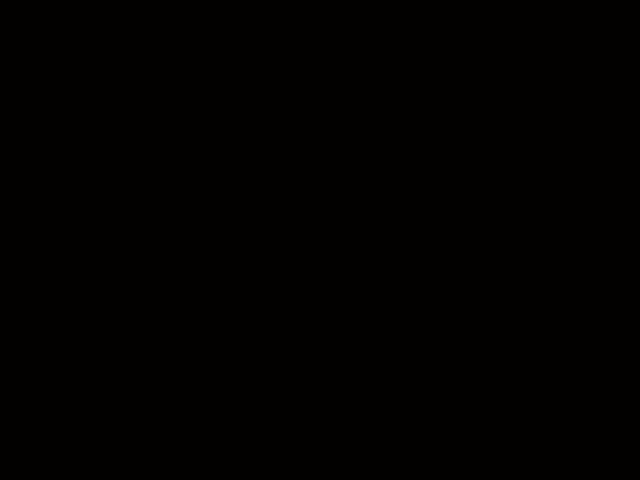

In [ ]:
cap = cv2.VideoCapture(camera_port)

ret, frame = cap.read()
cap.release()

if ret:
    _, buffer = cv2.imencode('.jpg', frame)
    display(Image(data=buffer.tobytes()))